In [569]:
import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path

In [570]:
DATA_PATH = r'C:\@Python Projects\TUT Research Project\Data\HZL_RA4_Pb_Rougher_2025-07.parquet'

df = pd.read_parquet(DATA_PATH)
df.sort_index(inplace=True)
print("Raw shape:", df.shape)

df.info(memory_usage='deep')

Raw shape: (21437, 115)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21437 entries, 2025-07-01 00:01:00.261502976 to 2025-07-30 19:21:38.179995904
Columns: 115 entries, MillFeedRate to month
dtypes: float64(113), int32(2)
memory usage: 18.8 MB


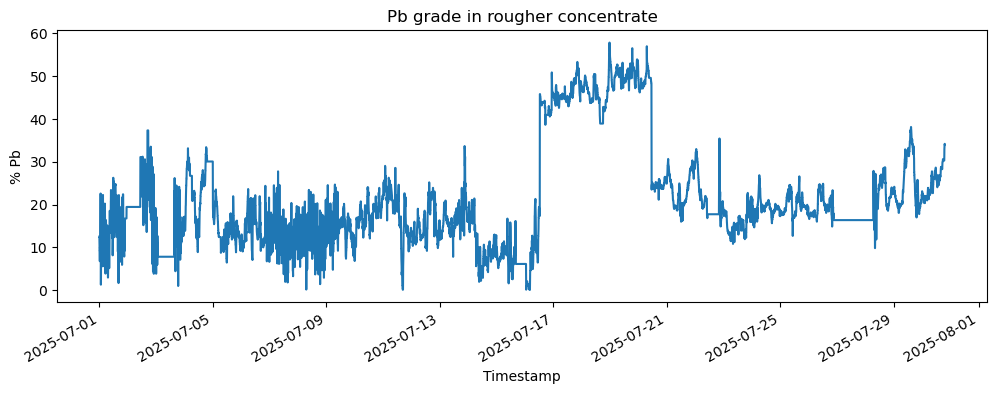

In [571]:
# %% Cell 16 ─ Quick sanity plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
df['Pb_Rougher_Conc_Pb'].plot(ax=ax, title='Pb grade in rougher concentrate')
ax.set_ylabel('% Pb')
plt.show()

Remove Duplicates

In [572]:
# %% Cell 4 ─ Ensure index is datetime & unique
df.index = pd.to_datetime(df.index, errors='coerce')
df = df.sort_index()
df = df[~df.index.duplicated(keep='first')]

:::Authority == 1 for every controlled unit
:::InvalidData == 0 for every unit that exposes it

In [573]:
# WS: Good start, but don't drop masked rows just yet.
# Instead, set their values to NaN so that when you add lagged features,
# you will see when a masked row is used in a lagged feature.
# Then at the end you drop all rows that contain NaNs so that you only have
# windows of time series data (the window is the lagged features) that are
# valid. Dropping the rows early may lead to errors later where suddenly your
# lagged feature that you think comes from 10 samples/50 minutes ago actually
# comes from a lot more than 50 minutes ago because of a gap between between
# two of those 10 samples (10 is just an example).
units = ['Pb_Rougher1', 'Pb_Rougher2', 'Pb_Scavenger1'] + \
        [f'Pb_Cleaner{i}' for i in (1,2,3)]
mask = pd.Series(True, index=df.index)
for u in units:
    if f'{u}_FSLSStatus' in df:
        mask &= df[f'{u}_FSLSStatus'] == 1
    if f'{u}_Authority' in df:
        mask &= df[f'{u}_Authority'] == 1
    if f'{u}_InvalidData' in df:
        mask &= df[f'{u}_InvalidData'] == 0
df = df[mask]

Drop columns with ≥ 95 % missing or zero-variance

In [574]:
missing = df.isna().mean()
near_all_nan = missing[missing >= 0.95]

variance = df.var()
near_zero_var = variance[variance < 1e-12]

drop_cols = near_all_nan.index.union(near_zero_var.index)
df = df.drop(columns=drop_cols)

In [575]:

# --- Get grade columns from Extract.ipynb mapping ---
grade_columns = [
    'Feed_Pb', 'Feed_Zn', 'Pb_Rougher_Conc_Pb', 'Pb_Rougher_Conc_Zn',
    'Pb_Final_Conc_Pb', 'Pb_Final_Conc_Zn', 'Pb_Scavenger_Tails_Pb', 'Pb_Scavenger_Tails_Zn'
]

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Invalid_Flat', errors='ignore')
col_ranges = {}
for col in numeric_cols:
    col_lower = col.lower()
    # Grades: fixed range 0-100
    if col in grade_columns:
        col_ranges[col] = (0, 100)
    # Valves/Flowrates: use _Min/_Max columns if present
    elif (('valve' in col_lower or 'rate' in col_lower) and not col_lower.endswith('_min') and not col_lower.endswith('_max')):
        min_col = f"{col}_Min"
        max_col = f"{col}_Max"
        if min_col in df.columns and max_col in df.columns:
            col_ranges[col] = (df[min_col].min(), df[max_col].max())
        else:
            # fallback to data min/max if no _Min/_Max columns
            col_ranges[col] = (df[col].min(), df[col].max())
    else:
        # fallback to data min/max for all others
        col_ranges[col] = (df[col].min(), df[col].max())

In [576]:
range_to_cols = defaultdict(list)
for col, rng in col_ranges.items():
    range_to_cols[rng].append(col)

Handle remaining NaNs
-Time-series forward-fill for continuous process variables (levels, -flows, valves, air).
-Clip outliers to 1st–99th percentile for each numeric column.
-Leave grade measurements untouched (they are sparse by nature).

In [577]:
# WS: 30 minutes is a big gap to fill, I wouldn't fill it but rather ignore those rows.
# Filling a 1-sample gap is probably fine, but a lot can happen in 30 minutes.
cont_vars = [c for c in df.columns if c.startswith(('Pb_', 'Feed_'))]
df[cont_vars] = df[cont_vars].ffill(limit=6)   # 30 min max gap
for c in cont_vars:
    lo, hi = df[c].quantile([.01, .99])
    df[c] = df[c].clip(lower=lo, upper=hi)

Re-index to equidistant 5-minute grid

In [578]:

cont_vars = [c for c in df.columns if c.startswith(('Pb_', 'Feed_'))]
df[cont_vars] = df[cont_vars].ffill(limit=1)

In [579]:
for c in cont_vars:
    lo, hi = df[c].quantile([.01, .99])
    df[c] = df[c].clip(lower=lo, upper=hi)

In [580]:
df = df.resample('5T').mean()

C:\Users\lusangom\AppData\Local\Temp\ipykernel_59124\614671958.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.resample('5T').mean()


Create derived targets & features
-Target: Pb_Rougher_Conc_Pb (or Pb_Final_Conc_Pb if final conc is the goal).
-Lagged reagent flows (KEX, Nigrosine, SIPX, NaCN) over 3-time-step window.
-Rolling means of air flow and level over 15 min.
-Feed grade ratios (Feed_Pb / (Feed_Pb + Feed_Zn)).

In [581]:
# 12a. Feed ratio
df['Feed_Pb_ratio'] = (
    df['Feed_Pb'] /
    (df['Feed_Pb'] + df['Feed_Zn'])
)

# 12b. Rolling 15-min means
for col in ['Pb_Rougher1_AirFlow', 'Pb_Rougher2_AirFlow']:
    if col in df:
        df[f'{col}_roll15'] = df[col].rolling('15T').mean()

# 12c. Lagged variables (5, 15, 30, 60 min)
lag_cols = [
    'Feed_Pb', 'Feed_Zn', 'Feed_Pb_ratio',
    'Pb_Rougher1_SIPX_Flowrate',
    'Pb_Rougher2_KEX_Flowrate',
    'Pb_Conditioner_KEX_Flowrate',
    'Pb_Conditioner_Nigrosine_Flowrate'
]
for c in lag_cols:
    if c in df:
        for lag in [1, 3, 6, 12]:   # 5, 15, 30, 60 min
            df[f'{c}_lag{lag*5}min'] = df[c].shift(lag)

C:\Users\lusangom\AppData\Local\Temp\ipykernel_59124\1974299002.py:10: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df[f'{col}_roll15'] = df[col].rolling('15T').mean()
C:\Users\lusangom\AppData\Local\Temp\ipykernel_59124\1974299002.py:10: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df[f'{col}_roll15'] = df[col].rolling('15T').mean()


In [582]:
# WS: Once you've added all the lagged features, the last thing to do is to drop rows that contain any NaNs.
df_final = df.dropna()
print("Final shape:", df_final.shape)

Final shape: (7584, 92)


Export to New File

In [583]:
Clean_DataPath = r'C:\@Python Projects\TUT Research Project\Clean_Data\HZL_RA4_Pb_Rougher_2025-07_clean.parquet'
df_final.to_parquet(Clean_DataPath)

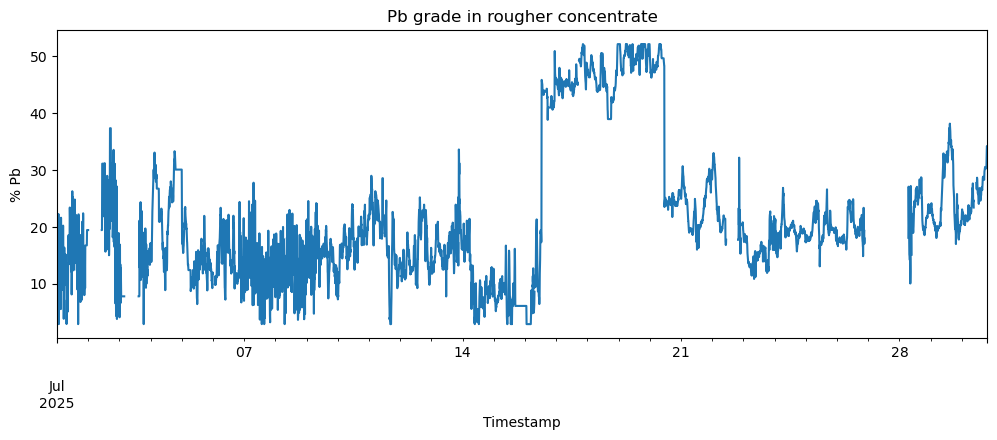

In [584]:
# %% Cell 16 ─ Quick sanity plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
df['Pb_Rougher_Conc_Pb'].plot(ax=ax, title='Pb grade in rougher concentrate')
ax.set_ylabel('% Pb')
plt.show()